# 📚 Clase: Curvas de Aprendizaje en Redes Neuronales


# 🧠 Arquitectura de una Red Neuronal Artificial (ANN)

Una ANN está compuesta por capas de **neuronas artificiales**, donde cada una realiza una transformación de los datos de entrada. Su estructura general se divide en:

1. **Capa de entrada**: recibe los datos iniciales (por ejemplo, pixeles de una imagen o parámetros observacionales).
2. **Capas ocultas**: una o más capas donde ocurren las combinaciones lineales y no lineales.
3. **Capa de salida**: genera la predicción final (valor continuo o categoría).

Cada **neurona** aplica una función del tipo:

$ z = \sum_{i} w_i x_i + b \quad ; \quad a = \phi(z) $

donde:
- $ w_i $ : pesos
- $ x_i $: entradas
- $ b $: sesgo (bias)
- $ \phi(z) $: función de activación (ReLU, Sigmoid, Tanh, etc.)

---

# 🔁 Propagación hacia adelante y hacia atrás

**Feedforward**: pasa los datos desde la entrada hasta la salida, aplicando pesos y activaciones.

**Backpropagation** (propagación hacia atrás) es el algoritmo que permite a una red neuronal **aprender**. Su objetivo es **ajustar los pesos y sesgos** para minimizar el error entre las salidas predichas y los valores reales. Este proceso consiste en:

1. **Calcular el error en la capa de salida**, usando una función de pérdida como MSE o entropía cruzada.
2. **Propagar ese error hacia atrás**, aplicando la regla de la cadena para calcular los gradientes (derivadas parciales) de la pérdida respecto a cada peso.
3. **Actualizar los pesos** con descenso de gradiente:

$ w_{ij}^{(t+1)} = w_{ij}^{(t)} - \eta \cdot \frac{\partial \mathcal{L}}{\partial w_{ij}} $

Donde:
- $ \eta $ es la tasa de aprendizaje
- $ \frac{\partial \mathcal{L}}{\partial w_{ij}} $ es el gradiente del error respecto al peso $ w_{ij} $

Este ciclo se repite durante muchas épocas, refinando los pesos para mejorar la precisión del modelo.

---

# 🔧 Hiperparámetros importantes

## ✨ Funciones de activación
- **ReLU**: f(x) = max(0, x) → rápida, ideal para capas ocultas.
- **Sigmoid**: salida entre 0 y 1 → usada en clasificación binaria.
- **Tanh**: salida entre -1 y 1 → centrada, usada cuando hay datos negativos.

Gráficamente, estas funciones tienen diferentes formas y efectos sobre la propagación y aprendizaje. ReLU es la más eficiente en redes profundas por evitar gradientes saturados.

## 🌿 Learning rate
- Define cuánto se ajustan los pesos en cada iteración.
- Tasa muy alta → el modelo se vuelve inestable.
- Tasa muy baja → aprendizaje muy lento.

**Curvas de aprendizaje**: se grafican la función de pérdida vs época para observar convergencia.

## 📊 Tamaño de batch y épocas
- **Batch size**: número de muestras procesadas antes de actualizar pesos.
   - Común: 16, 32, 64 o 128.
- **Épocas**: veces que el modelo recorre todo el conjunto de entrenamiento.
   - 10 a 200 suelen ser aceptables, dependiendo de los datos.

---

# 📉 Función de pérdida y optimización
- Regresión: Error cuadrático medio (MSE)
- Clasificación: Entropía cruzada

La pérdida se minimiza usando optimizadores como **SGD**, **Adam**, etc.

---

# ⚠️ Regularización
- **Dropout**: apaga aleatoriamente neuronas en entrenamiento
- **L2/L1**: penaliza pesos grandes
- **Early stopping**: detiene entrenamiento si no mejora el error de validación

In [1]:
from IPython.display import Markdown, display

def show_md(text):
    display(Markdown(text))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


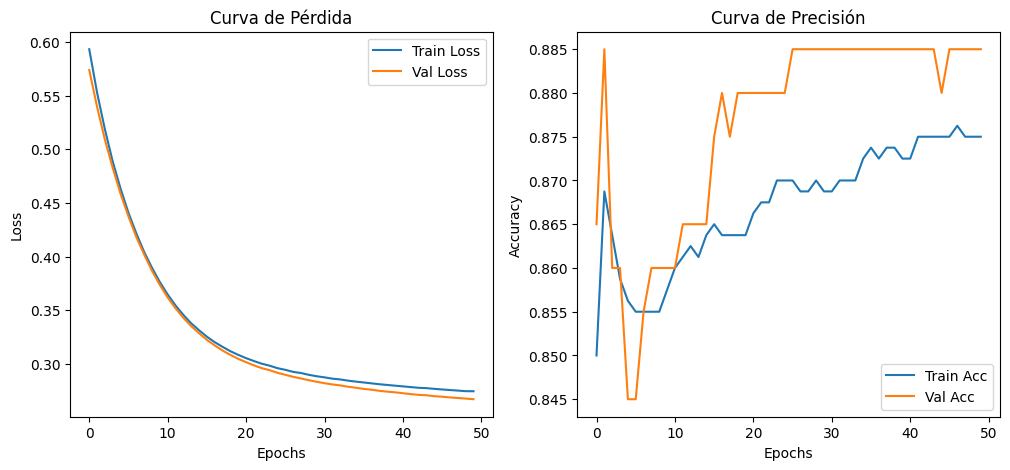

In [2]:
# --- Ejemplo con TensorFlow ---
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# Dataset simple
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

# Modelo simple
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Entrenamiento
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=0)

# Curvas de aprendizaje
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Curva de Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Curva de Precisión')
plt.legend()
plt.show()


## ❓ Preguntas de Análisis

1. **¿Cómo se comporta la pérdida durante el entrenamiento y validación?**



2. **¿En qué momento comienza el sobreajuste, si lo hay?**



3. **¿La red está aprendiendo de forma estable? ¿Podrías mejorar la arquitectura o los hiperparámetros?**



---

## ❓ Respuestas

1. **¿Cómo se comporta la pérdida durante el entrenamiento y validación?**

   - La pérdida de entrenamiento disminuye constantemente, lo que indica que el modelo está aprendiendo de los datos.
   - La pérdida de validación también disminuye, aunque a veces puede estabilizarse o aumentar, indicando sobreajuste leve si divergen.

2. **¿En qué momento comienza el sobreajuste, si lo hay?**

   - Si la curva de validación comienza a subir mientras la de entrenamiento sigue bajando, eso sugiere sobreajuste. En este caso puede observarse a partir de la época 35.

3. **¿La red está aprendiendo de forma estable? ¿Podrías mejorar la arquitectura o los hiperparámetros?**

   - Sí, en general las curvas son suaves y descendentes, lo que sugiere un aprendizaje estable.
   - Podríamos experimentar con redes más profundas, regularización, o cambiar la tasa de aprendizaje para mejorar.



### 📊 Comportamientos típicos:

- 🔁 Curvas paralelas (entrenamiento y validación): aprendizaje balanceado.
- 📉 Caída fuerte al inicio y estabilización: aprendizaje rápido y convergente.
- 🎢 Curvas con oscilaciones: tasa de aprendizaje alta o batch pequeño.
- ❌ Divergencia entre entrenamiento y validación: overfitting evidente.